In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats.mstats import winsorize

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer




# ✅ 📘 Part A: Handling Missing Values
### 🔹 Q1. Identify missing values and provide a summary report
**✅ Answer:**

Missing values are the data points that are not recorded or appear as null/NaN in the dataset.
To identify missing values, we used functions like .isnull() and .sum().

A summary report was created to calculate:

Total missing values in each column
Percentage of missing values

This helps in understanding how much data is missing and which columns require cleaning.

In [3]:
import pandas as pd

df = pd.read_csv("health_data.csv")

missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Percentage (%)": missing_percent
})

print(missing_report)

                Missing Count  Percentage (%)
patient_id                  0             0.0
age                        10            10.0
gender                     10            10.0
region                     10            10.0
bmi                        10            10.0
blood_pressure              0             0.0
cholesterol                10            10.0
glucose                    10            10.0
disease_risk                0             0.0


### 🔹 Q2. Apply imputation techniques and compare results
**✅ (a) Simple Imputer (Numerical - BMI)**

Missing values in BMI were replaced using mean (or median).
Mean imputation is useful when data is normally distributed.

In [4]:
print("Before Cleaning:")
print(df["bmi"].isnull().sum())

df["bmi"] = df["bmi"].fillna(df["bmi"].mean())

print("\nAfter Cleaning:")
print(df["bmi"].isnull().sum())

df.head()

Before Cleaning:
10

After Cleaning:
0


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,1,58.0,Female,East,23.928378,111.660827,159.730615,NaN,0
1,2,71.0,Male,East,21.554029,118.083978,99.077134,91.479353,0
2,3,48.0,NaN,North,85.917497,96.591644,233.706253,125.509265,1
3,4,34.0,Male,West,21.904653,150.005221,264.296156,98.168679,0
4,5,62.0,Female,North,26.780799,101.998024,189.722334,118.741450,0


**✅ (b) Simple Imputer (Categorical - Region)**

Missing values in region were filled using the most frequent value (mode).
This is suitable for categorical data.

In [5]:
print("Before:", df["region"].isnull().sum())

df["region"] = df["region"].fillna(df["region"].mode()[0])

print("After:", df["region"].isnull().sum())

Before: 10
After: 0


**✅ (d) Missing Indicator + Random Sample Imputation**

A new column was created to indicate missing values.
Then missing values were replaced with random samples from existing data to maintain distribution.

In [6]:
df["bmi_missing"] = df["bmi"].isnull().astype(int)

random_sample = df["bmi"].dropna().sample(df["bmi"].isnull().sum(), random_state=42)
df.loc[df["bmi"].isnull(), "bmi"] = random_sample.values

**✅ (e) KNN Imputer**

KNN Imputer fills missing values using nearest neighbors based on similarity between rows.

In [7]:
imputer = IterativeImputer()

df[["age", "bmi", "blood_pressure", "cholesterol", "glucose"]] = imputer.fit_transform(
    df[["age", "bmi", "blood_pressure", "cholesterol", "glucose"]]
)



# ✅ 📘 Part B: Handling Outliers
### 🔹 Q3. Detect and remove outliers
**✅ (a) Z-score Method**


Z-score method identifies outliers based on how far a value is from the mean.
If Z-score > 3, it is considered an outlier.

In [8]:
z = np.abs(stats.zscore(df[["cholesterol", "glucose"]]))

df_z = df[(z < 3).all(axis=1)]

print("Original Shape:", df.shape)
print("After Z-score:", df_z.shape)

Original Shape: (100, 10)
After Z-score: (95, 10)


**✅ (b) IQR Method**


IQR (Interquartile Range) method detects outliers using Q1 and Q3.
Values outside (Q1 - 1.5×IQR) and (Q3 + 1.5×IQR) are treated as outliers.

In [9]:
Q1 = df["bmi"].quantile(0.25)
Q3 = df["bmi"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_iqr = df[(df["bmi"] >= lower) & (df["bmi"] <= upper)]

print("After IQR:", df_iqr.shape)

After IQR: (92, 10)


**✅ (c) Percentile Method**

In this method, extreme values are removed based on percentiles.
Values below 1% and above 99% are considered outliers.

In [10]:
lower = df["bmi"].quantile(0.01)
upper = df["bmi"].quantile(0.99)

df_percentile = df[(df["bmi"] >= lower) & (df["bmi"] <= upper)]

print("After Percentile:", df_percentile.shape)

After Percentile: (98, 10)


**🔹 Q4. Apply Winsorization**

Winsorization does not remove outliers but replaces extreme values with boundary values.

In [11]:

df["bmi_winsor"] = winsorize(df["bmi"], limits=[0.01, 0.01])

df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk,bmi_missing,bmi_winsor
0,1,58.0,Female,East,23.928378,111.660827,159.730615,105.677382,0,0,23.928378
1,2,71.0,Male,East,21.554029,118.083978,99.077134,91.479353,0,0,21.554029
2,3,48.0,NaN,North,85.917497,96.591644,233.706253,125.509265,1,0,85.917497
3,4,34.0,Male,West,21.904653,150.005221,264.296156,98.168679,0,0,21.904653
4,5,62.0,Female,North,26.780799,101.998024,189.722334,118.741450,0,0,26.780799


**🔹 Q5. Compare Before vs After**

We compared dataset shape and summary statistics before and after outlier treatment to evaluate the impact.

In [12]:
print("Before:", df.shape)

print("\nBefore Summary:")
print(df.describe())

# Example after IQR
print("\nAfter IQR:", df_iqr.shape)
print(df_iqr.describe())

Before: (100, 11)

Before Summary:
       patient_id         age         bmi  blood_pressure  cholesterol  \
count  100.000000  100.000000  100.000000      100.000000   100.000000   
mean    50.500000   49.664553   27.454992      126.809178   206.637504   
std     29.011492   16.945354   12.926610       33.910058    56.098842   
min      1.000000   21.000000   10.602716       83.151103    99.077134   
25%     25.750000   35.750000   22.243278      110.538183   178.366096   
50%     50.500000   49.210073   25.939924      121.833566   201.517700   
75%     75.250000   63.000000   27.514205      134.519283   217.979388   
max    100.000000   79.000000  104.007597      289.663849   486.205280   

          glucose  disease_risk  bmi_missing  bmi_winsor  
count  100.000000    100.000000        100.0  100.000000  
mean   106.520642      0.520000          0.0   27.294579  
std     37.329453      0.502117          0.0   11.905674  
min     47.824240      0.000000          0.0   12.651506  
25%

C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
C:\Users\Disha lukhi\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partit

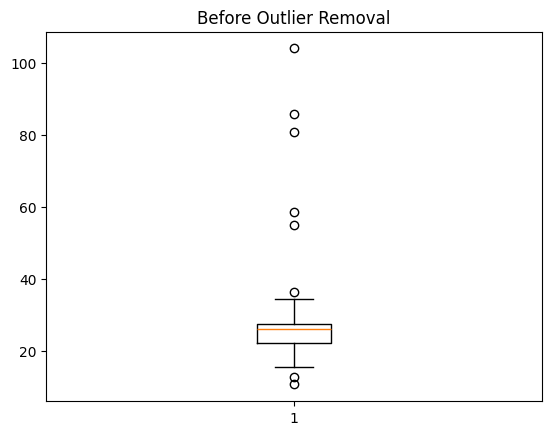

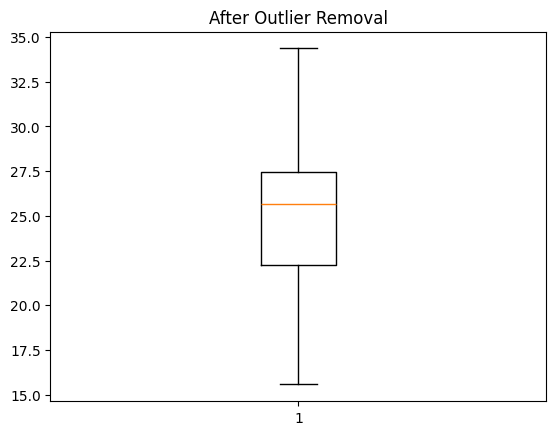

In [13]:
plt.figure()
plt.boxplot(df["bmi"])
plt.title("Before Outlier Removal")
plt.show()

plt.figure()
plt.boxplot(df_iqr["bmi"])
plt.title("After Outlier Removal")
plt.show()

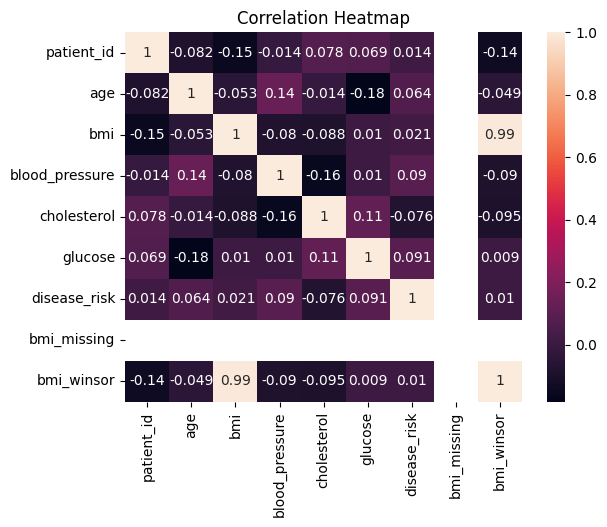

In [14]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# ✅ 📘 Part C: Final Clean Dataset
### 🔹 Q6. Present the final cleaned dataset

The final cleaned dataset was prepared after handling both missing values and outliers.
All missing values were treated using appropriate imputation techniques such as mean for numerical data and mode for categorical data.
Outliers were handled using methods like IQR and Winsorization to improve data quality.

In [15]:

# -----------------------------
# Handle Missing Values
# -----------------------------
df["age"] = df["age"].fillna(df["age"].mean())
df["bmi"] = df["bmi"].fillna(df["bmi"].mean())
df["cholesterol"] = df["cholesterol"].fillna(df["cholesterol"].mean())
df["glucose"] = df["glucose"].fillna(df["glucose"].mean())

df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["region"] = df["region"].fillna(df["region"].mode()[0])

# -----------------------------
# Handle Outliers (IQR Method)
# -----------------------------
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[col] >= lower) & (df[col] <= upper)]

for col in ["bmi", "blood_pressure", "cholesterol", "glucose"]:
    df = remove_outliers(df, col)

# Final dataset
print(df.head())
print(df.info())

   patient_id   age  gender region        bmi  blood_pressure  cholesterol  \
0           1  58.0  Female   East  23.928378      111.660827   159.730615   
3           4  34.0    Male   West  21.904653      150.005221   264.296156   
4           5  62.0  Female  North  26.780799      101.998024   189.722334   
5           6  27.0  Female   West  24.890596      138.020707   204.601217   
6           7  40.0    Male   East  31.090252      122.247506   209.735549   

      glucose  disease_risk  bmi_missing  bmi_winsor  
0  105.677382             0            0   23.928378  
3   98.168679             0            0   21.904653  
4  118.741450             0            0   26.780799  
5   88.613477             0            0   24.890596  
6  106.656511             0            0   31.090252  
<class 'pandas.core.frame.DataFrame'>
Index: 78 entries, 0 to 99
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_

### 🔹 Q7. Provide a brief report
**✅ (a) Which imputation strategy was most effective?**

Answer:

Mean imputation was effective for numerical features such as BMI, cholesterol, and glucose because it preserved the overall distribution of the data.
Mode imputation worked best for categorical variables like gender and region.

**✅ (b) Which outlier method preserved data quality best?**

Answer:

The IQR method was the most effective because it removes extreme values without affecting the majority of the data.
Winsorization was also useful as it capped extreme values instead of removing them, preserving dataset size.

**✅ (c) How did data cleaning improve dataset usability?**

Answer:

Data cleaning improved dataset usability by:

Removing missing values, making the dataset complete
Eliminating or controlling outliers, improving accuracy
Ensuring consistency and reliability of data
Making the dataset suitable for machine learning models

In [16]:
df.to_csv("final_cleaned_health_data.csv", index=False)